In [4]:
# Compare with SMRT
import sys
sys.path.append('E:/exps/lunar_scattering/lunar_regolith_scattering/mores/python')
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as C

from VRT import VRT
# from MORES import MORES
# from init_tools import init_surface_from_mores, init_layer_from_mores
from postprocessing import Mueller2sigma0VH
from TransparentSurface import TransparentSurface
# from SmoothSurface import SmoothSurface

from AIEM import AIEM
from RayleighSphere import RayleighSphere
from RayleighSpherekskaeps import RayleighSpherekskaeps
from dieletric_models import diel_soil

In [5]:
epsr_soil = diel_soil(3e9, 0.2, 30.6e-2, 13.5e-2, 23)

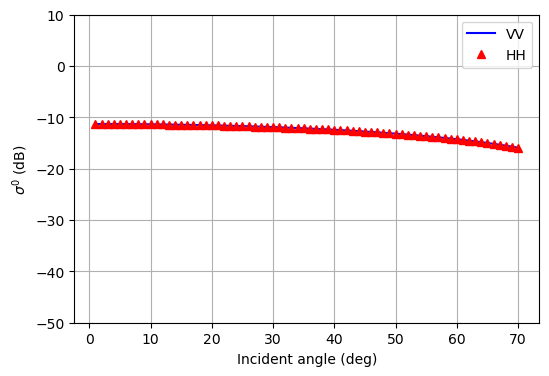

ks:0.1, ka:0.9, ke:1.0, ssa:0.1


In [12]:
freq = 3e9
ke = 1
a = 0.1
ks = ke * a
ka = ke - ks
epsr_bg = 1
d = 2.3
# subsurface
delta = 1e-2
corr_len = 10e-2
epsr2 = epsr_soil

c = C.speed_of_light
Lambda = c / freq
k = np.pi * 2 / Lambda
kdel = k * delta
kcor = k * corr_len

# freq = 10e9
# ke = 0.1
# a = 0.15
# ks = ke * a
# ka = ke - ks
# epsr_bg = 1
# d = 10
# # subsurface
# delta = 0.1e-2
# corr_len = 10e-2
# epsr2 = 6.28 - 1j * 1.53

# c = C.speed_of_light
# Lambda = c / freq
# k = np.pi * 2 / Lambda
# kdel = k * delta
# kcor = k * corr_len
##################################################################
surface = TransparentSurface(epsilon_r=epsr_bg)
# surface = SmoothSurface(epsilon_r=epsr_bg)
# layer = RayleighSphere(f=mores.freq, epsr_background=8.0, epsr_particle=3.2-3.2j, radius=0.05*3e8/mores.freq, fs=0.001, thickness=10)
layer = RayleighSpherekskaeps(f=freq, epsr_background=epsr_bg, ks=ks, ka=ka, thickness=d)
subsurface = AIEM(epsilon_r=epsr2, kdel=kdel, kcor=kcor, corr_fun='exp')

vrt = VRT(surface, layer, subsurface)
# run model and plot
theta_is = np.linspace(1, 70., 70)
Num = len(theta_is)
sigma0_VVs = np.zeros(Num)
sigma0_HHs = np.zeros(Num)
sigma0_HVs = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    # Mue_surface = vrt.Mue_
    # Mue = vrt.Mue_volume_nosurface((theta_i, 180, theta_i, 0))
    Mue_sur = vrt.Mue_surface((theta_i, 180, theta_i, 0))
    Mue_vol = vrt.Mue_volume((theta_i, 180, theta_i, 0))
    Mue_sub = vrt.Mue_subsurface((theta_i, 180, theta_i, 0))
    Mue_sub_vol = vrt.Mue_subsurface_volume((theta_i, 180, theta_i, 0))
    Mue_total = Mue_sur + Mue_vol + Mue_sub + Mue_sub_vol
    # Mue = vrt.Mue_volume((theta_i, 180, theta_i, 0)) + vrt.Mue_surface((theta_i, 180, theta_i, 0))
    Mue = Mue_vol
    sigma_VV, _, sigma_HV, sigma_HH = Mueller2sigma0VH(Mue)
    sigma0_VVs[i] = sigma_VV
    sigma0_HHs[i] = sigma_HH
    sigma0_HVs[i] = sigma_HV

sigma0_VV_dB = 10*np.log10(sigma0_VVs)
sigma0_HH_dB = 10*np.log10(sigma0_HHs)
sigma0_HV_dB = 10*np.log10(sigma0_HVs)
plt.figure(figsize=(6, 4))
plt.plot(theta_is, sigma0_VV_dB, 'b-', label='VV')
plt.plot(theta_is, sigma0_HH_dB, 'r^', label='HH')
# plt.plot(theta_is, sigma0_HV_dB, 'g--', label='HV')
plt.ylim(-50, 10)
plt.xlabel('Incident angle (deg)')
plt.ylabel('$\sigma^0$ (dB)')
plt.legend()
plt.grid()
plt.show()
layer.print_params()

In [7]:
kcor

6.287535065855046